In [1]:
pip install -U finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00


In [2]:

import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme()


def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def cal_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def cal_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def cal_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = cal_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(daily_ret, cum_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

def get_rebalancing_dates(close_data, period="month"):
    """
    리밸런싱 날짜 추출 (Pandas Grouper 활용)
    - 입력: 종가 데이터, 주기('month', 'quarter', 'year')
    - 출력: 리밸런싱 시행일(DatetimeIndex)
    """
    # 주기별 Pandas Frequency 문자열 매핑
    freq_map = {'month': 'ME', 'quarter': 'QE', 'year': 'YE'}

    # 1. 예외처리: 잘못된 주기 입력
    if period not in freq_map:
        raise ValueError("period must be 'month', 'quarter', or 'year'")

    freq = freq_map[period]

    rebalancing_dates = close_data.groupby(pd.Grouper(freq=freq)).apply(lambda x: x.index[-1])

    return rebalancing_dates.sort_index()


def cal_rebalancing_portfolio(close_data, period="month", weight_df=None, enable_plot=True):
    """
    리밸런싱 포트폴리오 성과 계산 (Chunk 방식)
    """
    # 1. 리밸런싱 날짜 구하기
    rebal_dates = get_rebalancing_dates(close_data, period)

    # 2. 초기 비중 설정 (없으면 동일 비중 1/N)
    if weight_df is None:
        n_assets = len(close_data.columns)
        weight_df = pd.DataFrame(
            index=rebal_dates,
            columns=close_data.columns,
            data=1/n_assets
        )

    # 3. 데이터 범위 보정 (비중 설정일 이후 데이터만 사용)
    first_date = weight_df.index[0]
    sub_data = close_data.loc[first_date:]

    # 4. 전체 기간 일별 수익률 미리 계산 (벡터화)
    daily_rets = sub_data.pct_change().fillna(0)

    portfolio_chunks = [] # 기간별 결과를 담을 리스트
    total_value = 1.0     # 초기 자산 (1.0 = 100%)

    # 5. 리밸런싱 기간별 순회 (Loop)
    full_dates = list(rebal_dates)
    if full_dates[-1] != sub_data.index[-1]:
        full_dates.append(sub_data.index[-1])

    for start, end in zip(full_dates[:-1], full_dates[1:]):

        current_weights = weight_df.loc[start]
        chunk_rets = daily_rets.loc[start:end].iloc[1:]

        if chunk_rets.empty: continue
        cum_growth = (1 + chunk_rets).cumprod()
        chunk_value = (cum_growth * current_weights).sum(axis=1) * total_value
        portfolio_chunks.append(chunk_value)
        total_value = chunk_value.iloc[-1]

    # 6. 결과 병합
    if not portfolio_chunks:
        return None, None

    portfolio_cum_ret = pd.concat(portfolio_chunks)
    portfolio_cum_ret.loc[first_date] = 1.0
    portfolio_cum_ret = portfolio_cum_ret.sort_index()

    # 일별 수익률 역산
    portfolio_day_ret = portfolio_cum_ret.pct_change().fillna(0)

    if enable_plot:
      # 결과 계산 (MDD 등)
      historical_max = portfolio_cum_ret.cummax()
      dd = (portfolio_cum_ret - historical_max) / historical_max * 100
      mdd = dd.min()

      tickers = close_data.columns.tolist() # 티커 리스트 추출
      daily_rets = close_data.pct_change().fillna(0) # 개별 종목 수익률 (배경 그리기용)

      # 시각화 함수 호출
      plot_portfolio_result(tickers, daily_rets, portfolio_cum_ret, dd, mdd)

    return portfolio_day_ret, portfolio_cum_ret



def plot_portfolio_result(tickers, daily_rets, port_cum_ret, dd, mdd):
    """
    포트폴리오 성과 시각화 함수
    - port_cum_ret : 포트폴리오 누적 수익률 (Series)
    - daily_rets   : 개별 자산 일별 수익률 (DataFrame)
    - dd           : 낙폭 데이터 (Series)
    - mdd          : 최대 낙폭 값 (float)
    - tickers      : 종목 코드 리스트 (list)
    """

    plt.figure(figsize=(8, 5))

    # [차트 1] 포트폴리오 누적 수익률 (Asset Growth)
    plt.subplot(2, 1, 1)

    # 1. 메인 포트폴리오 선 그리기
    plt.plot(port_cum_ret.index, port_cum_ret, label='Portfolio', color='#d62728', linewidth=1.5)

    # 2. 개별 종목 흐름 얇게 그리기 (비교용)
    # daily_rets가 있을 때만 그립니다.
    if daily_rets is not None and tickers is not None:
        for t in tickers:
            if t in daily_rets.columns:
                ind_cum = (1 + daily_rets[t]).cumprod()
                # 시작점을 포트폴리오와 맞추거나 1.0으로 통일
                # 여기선 데이터 자체의 흐름을 보기 위해 1.0 기준 계산값 사용
                plt.plot(ind_cum.index, ind_cum, label=f'{t}', alpha=0.3, linewidth=0.8, linestyle='--')

    plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5) # 본전 라인
    plt.title('Portfolio Cumulative Return', fontsize=14, fontweight='bold')
    plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='lightgray')
    # (참고) 만약 차트 '바깥' 왼쪽에 두고 싶다면 아래 주석을 사용하세요
    # plt.legend(bbox_to_anchor=(0, 1), loc='upper right')
    plt.grid(True, alpha=0.3)


    # [차트 2] 낙폭 (Drawdown)
    plt.subplot(2, 1, 2)

    plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3) # 파란색 채우기
    plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)       # 파란 실선

    plt.title('Portfolio Drawdown (MDD)', fontsize=12)
    plt.axhline(mdd, color='red', linestyle='--', label=f'Max DD: {mdd:.2f}%') # MDD 선

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()

def cal_AvgMomentumScore(close_data, n = 12):
    """
    평균 모멘텀 스코어를 기반으로 한 투자 비중 구하기
    close_data: 종가 데이터
    n: 모멘텀 기간 1~n
    return: 투자비중 weight df, 평균모멘텀 스코어 df
    """
    avgMomentumScore = 0 # 평모스 초기값
    priceOnRebalDate = close_data.loc[get_rebalancing_dates(close_data)] # 리밸런싱 일자의 가격 데이터

    # 1 ~ n개월 모멘텀 스코어 합
    for i in range(1, n+1):
        avgMomentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(i) > 1, 1, 0) + avgMomentumScore

    # 평모스 계산
    avgMomentumScore = pd.DataFrame(avgMomentumScore, index=priceOnRebalDate.index, columns=priceOnRebalDate.columns) # dataframe 형변환
    avgMomentumScore = avgMomentumScore / n

    # 모멘텀 스코어에 따른 weight 계산
    weight = avgMomentumScore.divide(avgMomentumScore.sum(axis=1), axis=0).fillna(0)
    # 투자 비중이 모두 0인 구간에서는 현금 보유
    weight['cash'] = np.where(weight.sum(axis=1) == 0, 1, 0)

    # 투자비중, 평모스 리턴
    return weight, avgMomentumScore

def get_heatmap(cumReturn):
    """
    cagr, dd, mdd 계산 및 히트맵(연간/월간 수익률) 시각화
    """
    # 1. CAGR 계산
    cagr = cumReturn.iloc[-1] ** (252/len(cumReturn))

    # 2. MDD 계산
    dd = (cumReturn.cummax() - cumReturn) / cumReturn.cummax() * 100
    mdd = dd.max()

    print(f"최종수익률: {cumReturn.iloc[-1]:.4f}\ncagr: {cagr:.4f}\nmdd: {mdd:.4f}%")

    # 3. 데이터프레임 변환 및 전처리
    cumReturn = pd.DataFrame(cumReturn)
    cumReturn.columns = ['cumReturn']
    cumReturn['year'] = cumReturn.index.year
    cumReturn['month'] = cumReturn.index.month

    # 월별/연별 마지막 데이터만 추출
    monthData = cumReturn.drop_duplicates(['year', 'month'], keep="last").copy()
    yearData = cumReturn.drop_duplicates('year', keep="last").copy()

    # 4. 수익률 계산
    monthData['monthReturn'] = monthData['cumReturn'].pct_change().fillna(0) * 100
    # 연간 수익률
    yearData['yearReturn'] = yearData['cumReturn'].pct_change().fillna(0) * 100
    # 첫 해 수익률 보정 (1.0에서 시작했다고 가정)
    yearData.iloc[0, -1] = (yearData.iloc[0, 0] - 1) * 100

    # 시각화를 위해 마지막 데이터의 '월'을 강제로 12로 설정 (연간 수익률 히트맵 정렬용)
    yearData.iloc[-1, yearData.columns.get_loc('month')] = 12

    # 5. 히트맵 시각화
    # 피벗 테이블 생성
    monthPivot = monthData.pivot(index='year', columns='month', values='monthReturn')
    yearPivot = yearData.pivot(index='year', columns='month', values='yearReturn')

    # 그래프 그리기
    # width_ratios=[1, 5]: 연간 수익률(왼쪽)은 좁게, 월간 수익률(오른쪽)은 넓게 설정
    f, (ax1, ax2) = plt.subplots(1, 2, sharey=True, gridspec_kw={'width_ratios': [1, 5]}, figsize=(20, 10))

    # 왼쪽: 연간 수익률
    sns.heatmap(yearPivot, ax=ax1, annot=True, fmt='.2f', linewidths=.3, cmap="RdYlGn", center=0, cbar=False)
    ax1.set_title("Annual Return")

    # 오른쪽: 월간 수익률
    sns.heatmap(monthPivot, ax=ax2, annot=True, fmt='.2f', linewidths=.1, cmap="RdYlGn", center=0, cbar=False)
    ax2.set_title("Monthly Return")

    plt.tight_layout()
    plt.show()

### 모멘텀 계산 방법

In [3]:
# 데이터 로드
kodex200 = get_close("069500", "2013", "2025-11-30")
kodex200

,Close
Date,
2013-10-24,21332
2013-10-25,21174
2013-10-28,21356
2013-10-29,21439
2013-10-30,21522
...,...
2025-11-24,54210
2025-11-25,54605
2025-11-26,56080


In [4]:
# 리밸런싱 일자
rebalDate = get_rebalancing_dates(kodex200)
rebalDate

,Close
Date,
2013-10-31,2013-10-31
2013-11-30,2013-11-29
2013-12-31,2013-12-30
2014-01-31,2014-01-29
2014-02-28,2014-02-28
...,...
2025-07-31,2025-07-31
2025-08-31,2025-08-29
2025-09-30,2025-09-30


In [5]:
# 리밸런싱 일자 종가 데이터
priceOnRebalDate =  kodex200.loc[rebalDate]
priceOnRebalDate

,Close
Date,
2013-10-31,21197
2013-11-29,21388
2013-12-30,21168
2014-01-29,20268
2014-02-28,20634
...,...
2025-07-31,43817
2025-08-29,43094
2025-09-30,47518


**n개월 모멘텀 = 현재 가격 / n개월 전 가격**  

In [6]:
# n개월 모멘텀 구하기
# n개월 모멘텀 = 현재 가격 / n개월 전 가격
# n개월 수익률과 같은 개념
n = 1
momentum = (priceOnRebalDate / priceOnRebalDate.shift(n)).fillna(0)
momentum

,Close
Date,
2013-10-31,0.000000
2013-11-29,1.009011
2013-12-30,0.989714
2014-01-29,0.957483
2014-02-28,1.018058
...,...
2025-07-31,1.057590
2025-08-29,0.983500
2025-09-30,1.102659


**n개월 모멘텀 스코어: if n개월 모멘텀 > 1, 1, 0**  


In [ ]:
# n개월 모멘텀 스코어
# n개월 모멘텀 스코어: if n개월 모멘텀 > 1, 1, 0
n = 1
momentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(n) > 1, 1, 0)
momentumScore

array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0])

**n개월 평균 모멘텀 스코어: 1~n개월 모멘텀 스코어의 평균**

In [ ]:
n = 12
avgMomentumScore = 0
for i in range(1, n1+):
    avgMomentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(i) > 1, 1, 0) + avgMomentumScore

avgMomentumScore = pd.DataFrame(avgMomentumScore, index=priceOnRebalDate.index)
# print(avgMomentumScore)
avgMomentumScore = avgMomentumScore / n
avgMomentumScore

,0
Date,
2013-10-31,0.000000
2013-11-29,0.083333
2013-12-30,0.000000
2014-01-29,0.000000
2014-02-28,0.083333
...,...
2025-07-31,1.000000
2025-08-29,0.916667
2025-09-30,1.000000


### 평균모멘텀 스코어에 따른 투자 비중 계산

In [11]:
# 데이터 로드
kodex200 = get_close("069500", "2000", "2025-11-30") # 코스피200 ETF
kodex10Bond = get_close("152380", "2000", "2025-11-30") # kodex 국고채 10년물 etf

# kodex200 = 069500
# kodex10Bond = 152380
# S&P500 = SPY
# 미국 7-10 국채 = IEF

closeDataSet = pd.concat([kodex200, kodex10Bond], axis=1)
closeDataSet.columns = ['kodex200', 'kodex10Bond']
closeDataSet.dropna(inplace=True)
closeDataSet

,kodex200,kodex10Bond
Date,,
2013-10-24,21332,54446
2013-10-25,21174,54496
2013-10-28,21356,54397
2013-10-29,21439,54397
2013-10-30,21522,54481
...,...,...
2025-11-24,54210,68155
2025-11-25,54605,68298
2025-11-26,56080,68357


In [12]:
# 리밸런싱 일자
rebalDate = get_rebalancing_dates(closeDataSet)
# 리밸런싱 일자 종가 데이터
priceOnRebalDate =  closeDataSet.loc[rebalDate]

In [13]:
# 12개월 평균모멘텀스코어 계산
n = 12
avgMomentumScore = 0
for i in range(1, n+1):
    avgMomentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(i) > 1, 1, 0) + avgMomentumScore
avgMomentumScore = pd.DataFrame(avgMomentumScore, index=priceOnRebalDate.index, columns=priceOnRebalDate.columns)
avgMomentumScore = avgMomentumScore / n
avgMomentumScore

,kodex200,kodex10Bond
Date,,
2013-10-31,0.000000,0.000000
2013-11-29,0.083333,0.000000
2013-12-30,0.000000,0.083333
2014-01-29,0.000000,0.083333
2014-02-28,0.083333,0.333333
...,...,...
2025-07-31,1.000000,0.833333
2025-08-29,0.916667,0.916667
2025-09-30,1.000000,0.333333


In [14]:
# 평균 모멘텀 스코어에 따른 투자 비중 계산
avgMomentumScore.sum(axis=1)

,0
Date,
2013-10-31,0.000000
2013-11-29,0.083333
2013-12-30,0.083333
2014-01-29,0.083333
2014-02-28,0.416667
...,...
2025-07-31,1.833333
2025-08-29,1.833333
2025-09-30,1.333333


In [ ]:
#평균 모멘텀점수의 정규화된 비중 계산
weight = avgMomentumScore.divide(avgMomentumScore.sum(axis=1), axis=0).fillna(0)
weight

,kodex200,kodex10Bond
Date,,
2013-10-31,0.000000,0.000000
2013-11-29,1.000000,0.000000
2013-12-30,0.000000,1.000000
2014-01-29,0.000000,1.000000
2014-02-28,0.200000,0.800000
...,...,...
2025-07-31,0.545455,0.454545
2025-08-29,0.500000,0.500000
2025-09-30,0.750000,0.250000


In [ ]:
# 주식, 채권의 비중이 모두 0인 구간에는 현금으로 보유합니다.
weight['cash'] = np.where(weight.sum(axis=1) == 0, 1, 0)
weight

,kodex200,kodex10Bond,cash
Date,,,
2013-10-31,0.000000,0.000000,1
2013-11-29,1.000000,0.000000,0
2013-12-30,0.000000,1.000000,0
2014-01-29,0.000000,1.000000,0
2014-02-28,0.200000,0.800000,0
...,...,...,...
2025-07-31,0.545455,0.454545,0
2025-08-29,0.500000,0.500000,0
2025-09-30,0.750000,0.250000,0


### 함수화

In [16]:
def getWeight_AvgMomentumScore(close_data, n = 12):
    """
    평균 모멘텀 스코어를 기반으로 한 투자 비중 구하기
    close_data: 종가 데이터
    n: 모멘텀 기간 1~n
    return: 투자비중 weight df, 평균모멘텀 스코어 df
    """
    avgMomentumScore = 0 # 평모스 초기값
    priceOnRebalDate = close_data.loc[get_rebalancing_dates(close_data)] # 리밸런싱 일자의 가격 데이터

    # 1 ~ n개월 모멘텀 스코어 합
    for i in range(1, n+1):
        avgMomentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(i) > 1, 1, 0) + avgMomentumScore

    # 평모스 계산
    avgMomentumScore = pd.DataFrame(avgMomentumScore, index=priceOnRebalDate.index, columns=priceOnRebalDate.columns) # dataframe 형변환
    avgMomentumScore = avgMomentumScore / n

    # 모멘텀 스코어에 따른 weight 계산
    weight = avgMomentumScore.divide(avgMomentumScore.sum(axis=1), axis=0).fillna(0)
    # 투자 비중이 모두 0인 구간에서는 현금 보유
    weight['cash'] = np.where(weight.sum(axis=1) == 0, 1, 0)

    # 투자비중, 평모스 리턴
    return weight, avgMomentumScore

In [17]:
closeDataSet

,kodex200,kodex10Bond
Date,,
2013-10-24,21332,54446
2013-10-25,21174,54496
2013-10-28,21356,54397
2013-10-29,21439,54397
2013-10-30,21522,54481
...,...,...
2025-11-24,54210,68155
2025-11-25,54605,68298
2025-11-26,56080,68357


In [18]:
weight6, avgMomentumScore6 = getWeight_AvgMomentumScore(closeDataSet, n=6)
weight12, avgMomentumScore12 = getWeight_AvgMomentumScore(closeDataSet, n=12)

In [19]:
pd.set_option('display.max_rows', None)

In [20]:
weight6

,kodex200,kodex10Bond,cash
Date,,,
2013-10-31,0.000000,0.000000,1
2013-11-29,1.000000,0.000000,0
2013-12-30,0.000000,1.000000,0
2014-01-29,0.000000,1.000000,0
2014-02-28,0.200000,0.800000,0
2014-03-31,0.285714,0.714286,0
2014-04-30,0.142857,0.857143,0
2014-05-30,0.400000,0.600000,0
2014-06-30,0.400000,0.600000,0


In [21]:
weight12

,kodex200,kodex10Bond,cash
Date,,,
2013-10-31,0.000000,0.000000,1
2013-11-29,1.000000,0.000000,0
2013-12-30,0.000000,1.000000,0
2014-01-29,0.000000,1.000000,0
2014-02-28,0.200000,0.800000,0
2014-03-31,0.285714,0.714286,0
2014-04-30,0.142857,0.857143,0
2014-05-30,0.363636,0.636364,0
2014-06-30,0.333333,0.666667,0


In [22]:
pd.reset_option('display.max_rows')

### 백테스트

#### **투자 비중이 0인 구간에는 현금을 보유. 따라서, closeDataSet에도 현금을 추가**

- 현금의 가격은 1로 간주합니다.
- 단기 예적금 등으로 1~2% 연 수익률을 얻을 수는 있지만,
- 보수적인 관점에서 백테스트하기 위함입니다.

In [ ]:
closeDataSet

,kodex200,kodex10Bond
Date,,
2013-10-22,21504,54140
2013-10-23,21265,54605
2013-10-24,21332,54446
2013-10-25,21174,54496
2013-10-28,21356,54397
2013-10-29,21439,54397
2013-10-30,21522,54481
2013-10-31,21197,54362
2013-11-01,21254,54189


In [23]:
closeDataSet['cash'] = 1
closeDataSet

,kodex200,kodex10Bond,cash
Date,,,
2013-10-24,21332,54446,1
2013-10-25,21174,54496,1
2013-10-28,21356,54397,1
2013-10-29,21439,54397,1
2013-10-30,21522,54481,1
...,...,...,...
2025-11-24,54210,68155,1
2025-11-25,54605,68298,1
2025-11-26,56080,68357,1


**12개월 평균 모멘텀 스코어 투자 비중을 이용한 백테스트**

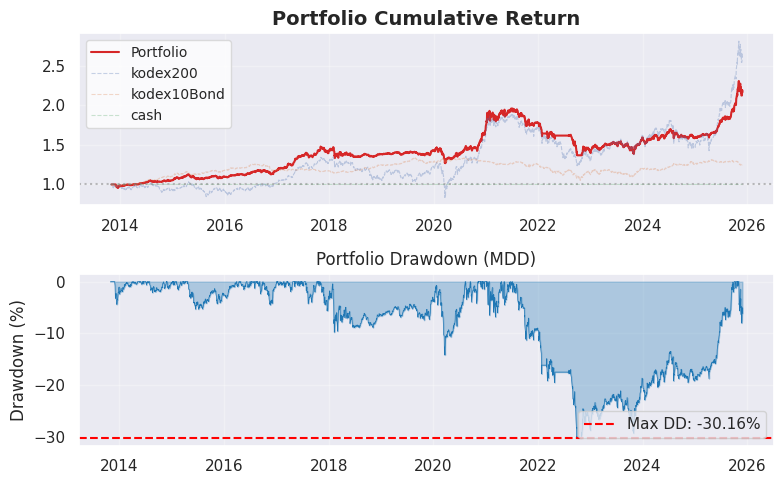

▶ 최종 수익률   : 116.48%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 6.78%
2. 안정성 (MDD)  : -30.16%
------------------------------
3. 연간 변동성   : 9.73%
4. 샤프 지수     : 0.5177


In [24]:
momentum12dayReturn, momentum12CumReturn = cal_rebalancing_portfolio(closeDataSet, weight_df=weight12)

cagr12, dd12, mdd12 = evaluate_performance(momentum12dayReturn, momentum12CumReturn )

**6개월 평균 모멘텀 스코어 투자 비중을 이용한 백테스트**

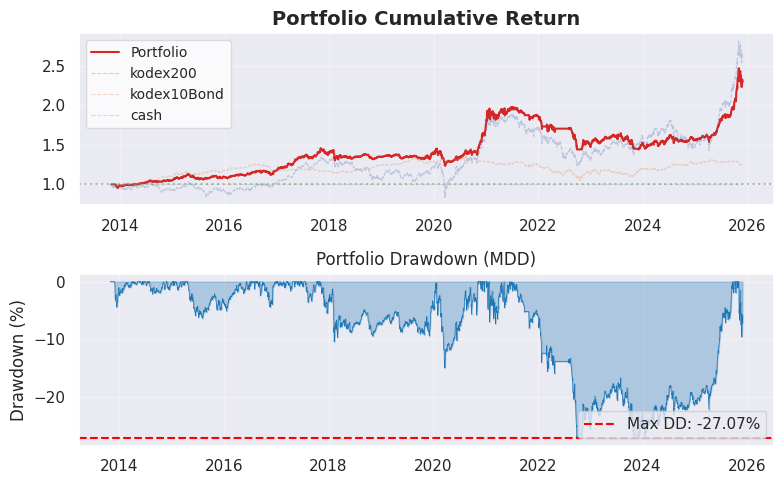

▶ 최종 수익률   : 129.13%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 7.30%
2. 안정성 (MDD)  : -27.07%
------------------------------
3. 연간 변동성   : 10.08%
4. 샤프 지수     : 0.5508


In [25]:
momentum6dayReturn, momentum6CumReturn = cal_rebalancing_portfolio(closeDataSet, weight_df=weight6)

cagr6, dd6, mdd6 = evaluate_performance(momentum6dayReturn, momentum6CumReturn )

**시장수익률 계산 (코스피200)**

In [26]:
rebalDate = get_rebalancing_dates(closeDataSet)
rebalDate

,0
Date,
2013-10-31,2013-10-31
2013-11-30,2013-11-29
2013-12-31,2013-12-30
2014-01-31,2014-01-29
2014-02-28,2014-02-28
...,...
2025-07-31,2025-07-31
2025-08-31,2025-08-29
2025-09-30,2025-09-30


In [27]:
stockDayReturn = cal_daily_return(kodex200.loc[rebalDate.iloc[0]:])
stockCumReturn = cal_cum_return(kodex200.loc[rebalDate.iloc[0]:])
stockCagr, stockDD, stockMDD = evaluate_performance(stockDayReturn, stockCumReturn)

▶ 최종 수익률   : 162.54%
=== 성과 평가 리포트 ===
1. 수익성 (CAGR) : 8.55%
2. 안정성 (MDD)  : -38.09%
------------------------------
3. 연간 변동성   : 17.29%
4. 샤프 지수     : 0.4452


In [28]:
# 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,961 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direc

In [29]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 폰트 경로 지정 (NanumBarunGothic)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 폰트 파일이 존재하는지 확인하고 추가
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
else:
    print("폰트 파일을 찾을 수 없습니다. 설치가 제대로 되었는지 확인해주세요.")

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

**시각화 비교**

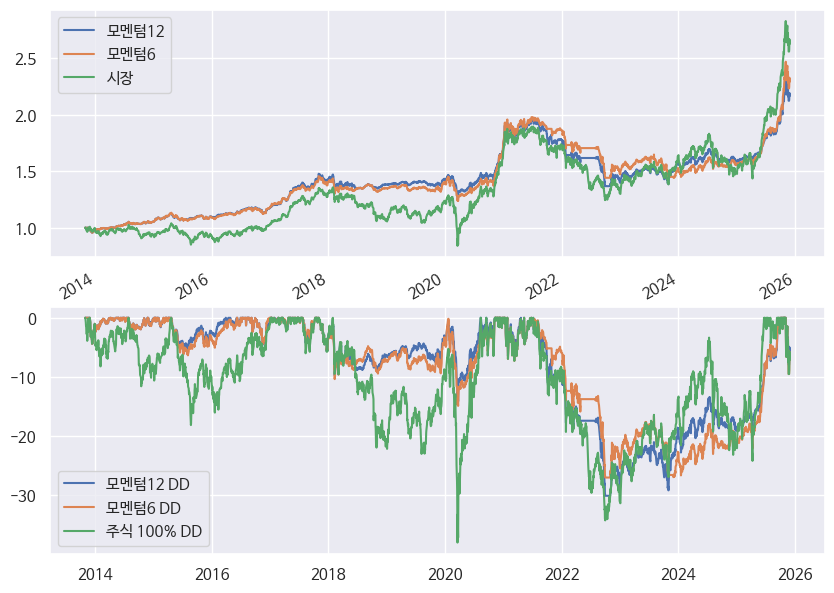

In [30]:
plt.figure(figsize=(10,8))

# 수익곡선
plt.subplot(2,1,1)
momentum12CumReturn.plot(label="모멘텀12")
momentum6CumReturn.plot(label="모멘텀6")
stockCumReturn.plot(label="시장")
plt.legend()

# dd 곡선
plt.subplot(2,1,2)
plt.plot(dd12, label="모멘텀12 DD")
plt.plot(dd6, label="모멘텀6 DD")
plt.plot(stockDD, label="주식 100% DD")
plt.legend()

plt.show()

### 실습

* 10년물 채권에서 20년물 채권으로 바꿔서 백테스트를 해본다면?  
(장기채권은 단기채권에 비해 변동성이 높습니다.)  
  
* 미국 자산으로 평균 모멘텀 스코어 전략을 백테스트 해본다면?(tqqq, tlt 등 )

# 새 섹션

/tmp/ipython-input-1032409469.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  first_date = rebal_dates[0]
/tmp/ipython-input-1032409469.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  first_date = rebal_dates[0]
/tmp/ipython-input-1032409469.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  first_date = rebal_dates[0]


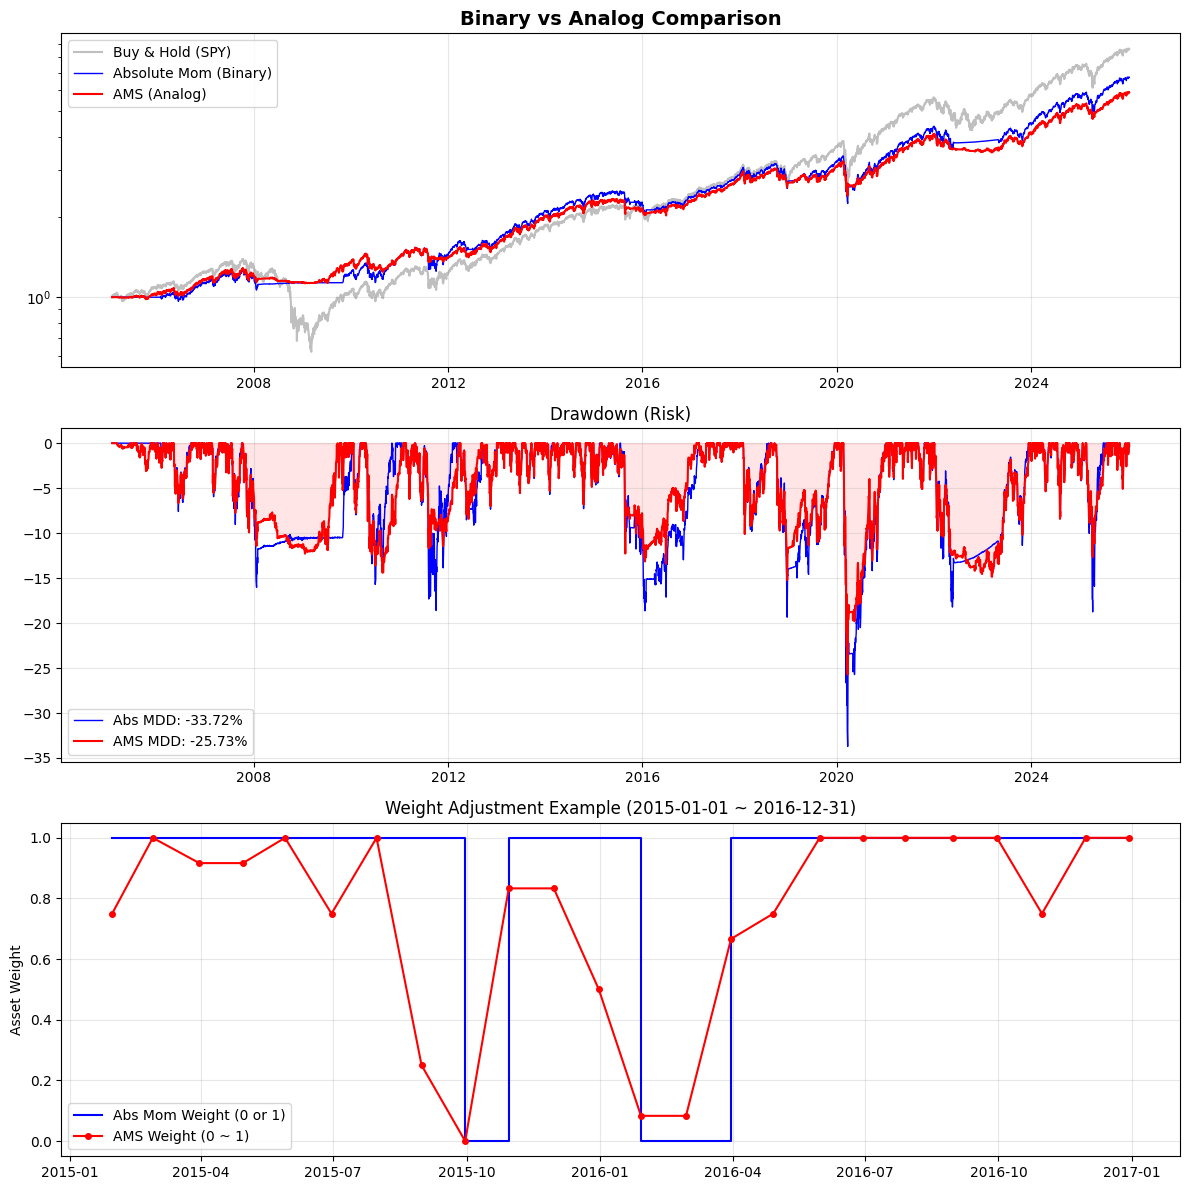

AMS Final Return: 5.91x (MDD: -25.73%)
Abs Final Return: 6.73x (MDD: -33.72%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('ETF 유니버스.csv', index_col=0)
df.index = pd.to_datetime(df.index)

# 현금 자산 설정 (BIL이 없으면 1.0으로 가정)
close_data = df.copy()
if 'BIL' in close_data.columns:
    close_data['cash'] = close_data['BIL']
else:
    close_data['cash'] = 1.0


target_asset = 'SPY'
asset_data = close_data[[target_asset]]

# 1. Strategy B: AMS (Analog)
# 함수 호출 (점수만 가져와서 씁니다)
_, ams_score_df = getWeight_AvgMomentumScore(asset_data, n=12)

# 실제 투자 비중 생성 (점수만큼 투자, 나머지는 현금)
weight_ams = pd.DataFrame(index=ams_score_df.index)
weight_ams[target_asset] = ams_score_df[target_asset]
weight_ams['cash'] = 1 - weight_ams[target_asset]

# 2. Strategy A: Absolute Momentum (Binary)
# 12개월 수익률이 +면 100%, 아니면 0%
rebal_dates = ams_score_df.index
price_monthly = asset_data.loc[rebal_dates]
abs_signal = np.where(price_monthly / price_monthly.shift(12) > 1, 1.0, 0.0)

weight_abs = pd.DataFrame(abs_signal, index=rebal_dates, columns=[target_asset])
weight_abs['cash'] = 1 - weight_abs[target_asset]

# 3. Buy & Hold
weight_bh = pd.DataFrame(index=rebal_dates)
weight_bh[target_asset] = 1.0
weight_bh['cash'] = 0.0

# 백테스팅 실행
backtest_data = close_data[[target_asset, 'cash']].copy()
cum_ams = cal_rebalancing_portfolio(backtest_data, weight_df=weight_ams)
cum_abs = cal_rebalancing_portfolio(backtest_data, weight_df=weight_abs)
cum_bh = cal_rebalancing_portfolio(backtest_data, weight_df=weight_bh)

# ---------------------------------------------------------
# 시각화
# ---------------------------------------------------------
plt.figure(figsize=(12, 12))

# 1. 수익률 곡선
plt.subplot(3, 1, 1)
plt.plot(cum_bh, label='Buy & Hold (SPY)', color='gray', alpha=0.5)
plt.plot(cum_abs, label='Absolute Mom (Binary)', color='blue', linewidth=1)
plt.plot(cum_ams, label='AMS (Analog)', color='red', linewidth=1.5)
plt.title('Binary vs Analog Comparison', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 2. MDD 곡선
def get_dd(cum): return (cum / cum.cummax() - 1) * 100
dd_abs = get_dd(cum_abs)
dd_ams = get_dd(cum_ams)

plt.subplot(3, 1, 2)
plt.plot(dd_abs, label=f'Abs MDD: {dd_abs.min():.2f}%', color='blue', linewidth=1)
plt.plot(dd_ams, label=f'AMS MDD: {dd_ams.min():.2f}%', color='red', linewidth=1.5)
plt.fill_between(dd_ams.index, dd_ams, 0, color='red', alpha=0.1)
plt.title('Drawdown (Risk)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

# 3. 비중 변화 (2015-2016 구간 확대)
plt.subplot(3, 1, 3)
zoom_start, zoom_end = '2015-01-01', '2016-12-31'
w_abs_zoom = weight_abs.loc[zoom_start:zoom_end]
w_ams_zoom = weight_ams.loc[zoom_start:zoom_end]

plt.plot(w_abs_zoom[target_asset], label='Abs Mom Weight (0 or 1)', drawstyle='steps-post', color='blue')
plt.plot(w_ams_zoom[target_asset], label='AMS Weight (0 ~ 1)', color='red', marker='o', markersize=4)
plt.title(f'Weight Adjustment Example ({zoom_start} ~ {zoom_end})', fontsize=12)
plt.ylabel('Asset Weight')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 결과 출력
print(f"AMS Final Return: {cum_ams.iloc[-1]:.2f}x (MDD: {dd_ams.min():.2f}%)")
print(f"Abs Final Return: {cum_abs.iloc[-1]:.2f}x (MDD: {dd_abs.min():.2f}%)")